# Style Model Architecture Comparison

## 1. Objective

The objective of this notebook is to compare different model architectures for the fashion style classification task.

So far, the project has mainly used a ResNet34-based classifier for style prediction. This model was used as the baseline architecture in earlier style classification experiments and was later improved by adding extra targeted training data. The dataset-improved ResNet34 model achieved the best real-world style classification result so far, improving real-world accuracy from **0.4750** to **0.6000**.

However, the recommendation evaluation still showed that style prediction remains one of the main weaknesses of the full system. When the style classifier predicts the wrong style, the recommendation system retrieves items from the wrong style category. This can result in recommendations that are structurally valid, but not stylistically useful.

Based on teacher feedback, a relevant next step is to investigate whether different model architectures perform better than the current ResNet34 approach. In particular, models such as MobileNet and EfficientNet are worth testing because they may behave differently in terms of accuracy, generalization, and resource usage.

This notebook compares the following architectures:

- ResNet34
- MobileNetV3 Large
- EfficientNet-B0

The main research question for this experiment is:

_Does a different pretrained model architecture improve real-world fashion style classification compared with the current ResNet34 model?_

## 2. Project Context

The overall project is a fashion recommendation system that suggests clothing items based on an input image.

The system currently uses two classification models:

- a style classifier
- a clothing type classifier

The style classifier predicts the fashion style of the input item. The current style classes are:

- formal
- gothic
- sporty
- streetwear

The clothing type classifier predicts the type of clothing item. The current clothing type classes are:

- jacket
- pants
- shoes
- tshirt

These predictions are used by the recommendation system. The recommender retrieves catalogue items with the same predicted style and a different predicted clothing type. After filtering the catalogue, the system ranks candidate items using image embeddings and cosine similarity.

Because of this, the style classifier has a direct influence on recommendation quality. If the style prediction is wrong, the system searches in the wrong style category. For example, if a gothic t-shirt is predicted as streetwear, the recommender will return streetwear items instead of gothic items.

Previous experiments showed that improving the dataset helped the style classifier generalize better to real-world images. However, the model still struggles with some boundary cases, especially between gothic, sporty, and streetwear. This suggests that the next step should not only focus on adding more data, but also on testing whether another model architecture can learn the style differences more effectively.

This experiment therefore focuses only on the style classification task. The clothing type classifier is not changed in this notebook, because previous experiments showed that the improved type classifier already performs relatively well on real-world images.

## 3. Why This Experiment Is Needed

This experiment is needed because the current project has reached a point where the main remaining issue is no longer the basic recommendation logic, but the reliability of the style classifier.

Earlier experiments showed that the recommendation pipeline can produce useful results when the style and clothing type predictions are correct. The embedding-based recommender can retrieve items from the correct style category and rank them based on visual similarity. However, when the style prediction is wrong, the recommendations become less useful because the system retrieves items from the wrong style group.

The current selected style model is based on ResNet34 with extra targeted training data. This improved real-world performance compared with the original baseline, but the result is still limited. The model improved streetwear recognition, but it also created new confusion between streetwear, gothic, and sporty items.

Teacher feedback also pointed toward testing and understanding different model architectures, especially models such as MobileNet and EfficientNet. This makes architecture comparison a logical next step.

The goal of this experiment is not to randomly try many models. Instead, the goal is to make a controlled comparison between a small number of relevant architectures. This makes it possible to observe whether the architecture itself affects real-world generalization.

This experiment should help answer the following questions:

- Does MobileNetV3 perform well enough while using fewer resources?
- Does EfficientNet-B0 generalize better than ResNet34 on real-world clothing images?
- Does any architecture reduce confusion between gothic, sporty, and streetwear?
- Is the current ResNet34 model still the best choice for the prototype?
- Which model should be used in the next recommendation pipeline experiment?

## 4. Model Selection Rationale

The selected models were chosen based on clear project constraints instead of testing random architectures.

The goal of this experiment is to compare architectures that are relevant, feasible, and different enough to provide useful observations. Since the dataset is relatively small, all selected models use pretrained ImageNet weights and transfer learning. This makes the experiment more realistic because training a deep image model from scratch would require much more data and computing power.

The selected architectures are:

- ResNet34
- MobileNetV3 Large
- EfficientNet-B0

These models were selected using the following criteria:

| Criterion | Reason |
|---|---|
| Relevance to image classification | The task is to classify clothing images into fashion style categories. |
| Pretrained weights available | The dataset is small, so transfer learning is needed. |
| Feasible within the project timeline | The models should be possible to train and evaluate within the semester. |
| Different architecture behaviour | The models should represent different trade-offs, not only small variations of the same idea. |
| Resource usage | The professor mentioned that resource usage should be considered, especially when using AI-based approaches. |
| Comparison with previous work | ResNet34 must be included because earlier experiments are based on it. |
| Usefulness for conclusion | Each model should help answer a different question about performance, efficiency, or generalization. |

ResNet34 is included as the current baseline. It allows the experiment to compare new architectures against the model that has already been used throughout the project.

MobileNetV3 Large is included because it is designed to be lightweight and efficient. This makes it useful for checking whether a smaller model can still achieve acceptable classification performance while using fewer resources.

EfficientNet-B0 is included because it is a modern CNN architecture that balances accuracy and efficiency. It may generalize better than ResNet34 while still being feasible to train in the current project setup.

The purpose is not to find the most advanced model possible. The purpose is to make a controlled comparison between architectures that are suitable for the project scope.

## 5. Models Considered but Not Selected

Several other model architectures were considered, but they were not selected for this first architecture comparison.

The reason for this is scope control. Testing too many models would make the experiment harder to interpret and would take time away from analysing the results properly. Since the teacher feedback specifically mentioned comparing models such as MobileNet and EfficientNet, this first comparison focuses on those models together with the current ResNet34 baseline.

| Model | Why it was not selected for this first comparison |
|---|---|
| VGG16 | VGG16 is an older and heavier architecture. It has many parameters and is less efficient compared with newer models. |
| DenseNet121 | DenseNet121 is interesting for image classification, but it is less directly connected to the teacher feedback than MobileNet and EfficientNet. |
| ConvNeXt-Tiny | ConvNeXt-Tiny is a strong modern architecture, but it may make the experiment more advanced than needed for this step. |
| Vision Transformer | Vision Transformers usually need more data or careful tuning. This may be risky with the current dataset size. |
| CLIP | CLIP is very relevant for fashion similarity and image-text understanding, but it would change the project direction more than a simple model architecture comparison. |

These models can still be useful in future work. For example, CLIP could be interesting later for improving the embedding-based recommendation ranking, because it can represent images using more semantic features. However, for this experiment, the focus stays on comparing CNN-based image classification models under the same conditions.

## 6. Approach

This experiment compares three model architectures for the style classification task.

The comparison follows a controlled setup. The dataset, class labels, preprocessing, training strategy, and evaluation sets should stay the same for each model. The only major difference should be the model architecture.

The experiment follows these steps:

1. Load the improved style classification dataset.
2. Use the same four style classes:
   - formal
   - gothic
   - sporty
   - streetwear
3. Train three pretrained model architectures:
   - ResNet34
   - MobileNetV3 Large
   - EfficientNet-B0
4. Replace the final classification layer of each model so it outputs four style classes.
5. Freeze the pretrained feature extractor at first and train only the final classification layer.
6. Evaluate each model on the curated test set.
7. Evaluate each model on the separate real-world test set.
8. Compare the results using accuracy, macro F1-score, per-class recall, confusion matrices, model size, and inference time.
9. Select the most suitable model based mainly on real-world performance.
10. Use the selected model in a later recommendation pipeline experiment.

The main focus is real-world performance. Previous experiments showed that curated test accuracy can be misleading, because a model can perform well on clean images but still struggle with realistic images. Because of this, the real-world test set is used as the most important evaluation source.

The expected result is not automatically that a new model will perform better. It is also possible that ResNet34 remains the best choice. In that case, the experiment is still useful because it shows that the architecture was tested and that the final choice is based on evidence instead of assumption.

## 7. Experiment Design

The experiment is designed as a controlled model architecture comparison.

To make the comparison fair, the same dataset, preprocessing, training settings, and evaluation method should be used for each architecture. The only main variable that changes is the model architecture.

The models compared in this experiment are:

| Model | Role in experiment |
|---|---|
| ResNet34 | Current baseline model |
| MobileNetV3 Large | Lightweight architecture comparison |
| EfficientNet-B0 | Modern efficient CNN comparison |

The style classes remain the same as in the previous experiments:

| Class index | Style class |
|---:|---|
| 0 | formal |
| 1 | gothic |
| 2 | sporty |
| 3 | streetwear |

The experiment uses the improved style dataset, which includes the original style training data and extra targeted images. This dataset is used because it produced the best real-world style result so far with ResNet34.

The same real-world test set is used for all models. This is important because the real-world test set represents the type of input images the final recommendation system should handle.

The experiment should keep the following setup consistent:

| Factor | Fixed value |
|---|---|
| Task | Fashion style classification |
| Number of classes | 4 |
| Classes | formal, gothic, sporty, streetwear |
| Dataset | Improved style dataset |
| Input image size | 224 x 224 |
| Pretraining | ImageNet pretrained weights |
| Training strategy | Transfer learning |
| Initial training setup | Frozen feature extractor, train classifier head |
| Random seed | 42 |
| Evaluation sets | Curated test set and real-world test set |
| Main comparison focus | Real-world generalization |

This design makes the results easier to interpret. If one model performs better than another, the difference is more likely caused by the architecture rather than unrelated changes in the experiment setup.

## 8. Evaluation Metrics

The models are evaluated using both general classification metrics and practical deployment-related metrics.

Accuracy is useful as a simple overall score, but it is not enough by itself. The dataset contains multiple style classes, and previous experiments showed that some classes are more difficult than others. For example, streetwear, gothic, and sporty can visually overlap. Because of this, per-class metrics are also needed.

The following metrics are used:

| Metric | Why it is used |
|---|---|
| Accuracy | Shows the overall percentage of correct predictions. |
| Macro F1-score | Gives a balanced score across all classes, even when one class performs worse. |
| Precision per class | Shows how often predictions for a class are correct. |
| Recall per class | Shows how many true examples of a class are correctly found. |
| Confusion matrix | Shows which classes are confused with each other. |
| Model size | Shows how large the trained model is. |
| Inference time | Shows how fast the model makes predictions. |

The most important evaluation results are the real-world accuracy and real-world macro F1-score.

The curated test set is still useful, but it should not be the only decision factor. Earlier experiments showed that a model can perform well on curated data while performing worse on realistic images. Therefore, the model selection should prioritize real-world performance.

Special attention should be given to the following class-level results:

- gothic recall
- sporty recall
- streetwear recall
- confusion between gothic and streetwear
- confusion between sporty and streetwear

These are important because previous experiments showed that the recommendation system is mainly limited by style boundary errors.

## 9. Expected Comparison Table

After training and evaluating all models, the results should be summarized in one comparison table.

The table should include both performance metrics and practical resource-related metrics.

| Model | Curated accuracy | Curated macro F1 | Real-world accuracy | Real-world macro F1 | Formal recall | Gothic recall | Sporty recall | Streetwear recall | Model size | Avg inference time |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| ResNet34 | ... | ... | ... | ... | ... | ... | ... | ... | ... | ... |
| MobileNetV3 Large | ... | ... | ... | ... | ... | ... | ... | ... | ... | ... |
| EfficientNet-B0 | ... | ... | ... | ... | ... | ... | ... | ... | ... | ... |

This table will make it easier to compare the models and choose the most suitable architecture for the next recommendation experiment.

The best model is not necessarily the model with the highest curated test accuracy. The final choice should be based mainly on:

1. real-world accuracy,
2. real-world macro F1-score,
3. class-level performance on difficult styles,
4. resource usage,
5. suitability for the recommendation pipeline.

If one model has slightly lower accuracy but is much smaller and faster, it may still be useful depending on the final application requirements. However, if the main goal is improving recommendation quality, real-world style reliability should remain the most important factor.

## 10. Import Libraries

The notebook uses PyTorch and torchvision to train and evaluate the different model architectures. Pandas and NumPy are used for storing and comparing results. Scikit-learn is used for classification metrics such as accuracy, macro F1-score, classification reports, and confusion matrices. Matplotlib is used to visualize confusion matrices.

The experiment also measures model size and inference time, because the comparison should include both performance and resource usage.

In [1]:
import os
import time
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## 11. Reproducibility and Device Setup

To make the experiment more reproducible, the random seeds are fixed for Python, NumPy, and PyTorch.

The notebook also checks whether CUDA or Apple MPS is available. If a GPU is available, it is used for training and evaluation. Otherwise, the experiment runs on CPU.

Using the same seed does not guarantee completely identical results in every environment, but it helps reduce randomness between runs.

In [2]:
# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Device setup
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device: CUDA")
    print("GPU:", torch.cuda.get_device_name(0))
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

print("Torch version:", torch.__version__)

Using device: CUDA
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Torch version: 2.11.0+cu130


## 12. Paths and Results Folder

This experiment uses the original style classification split together with the extra targeted style training images.

The base style dataset is loaded from `split_style`. This contains the original train, validation, and test split for the style classifier.

The `style_extra` folder is also used during training because the current improved ResNet34 style model was trained with extra targeted images. This makes the architecture comparison fair, because each model is tested using the same improved training setup.

The `real_world_test` folder is kept separate and is only used for evaluation. This prevents data leakage and keeps the real-world evaluation fair.

A separate results folder is created for this architecture comparison experiment.

In [10]:
# Dataset paths
style_dataset_root = "../dataset/split_style"
style_extra_root = "../dataset/style_extra"
real_world_dir = "../dataset/real_world_test"

# Results folder
results_dir = "../results/style_architecture_comparison"
os.makedirs(results_dir, exist_ok=True)

print("Style dataset path:", style_dataset_root)
print("Style extra data path:", style_extra_root)
print("Real-world test path:", real_world_dir)
print("Results folder:", results_dir)

Style dataset path: ../dataset/split_style
Style extra data path: ../dataset/style_extra
Real-world test path: ../dataset/real_world_test
Results folder: ../results/style_architecture_comparison


## 13. Data Transforms

The same image preprocessing is used for all three architectures to keep the comparison fair.

All images are resized to 224 by 224 pixels, converted to tensors, and normalized using ImageNet mean and standard deviation values. This matches the preprocessing expected by the pretrained models.

For the training set, simple data augmentation is used. The goal is to make the models less dependent on exact image position and small visual differences. The validation, curated test, and real-world test sets do not use augmentation, because evaluation should be stable and consistent.

In [11]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 14. Load Curated Style Dataset

The curated style dataset is loaded using `ImageFolder`.

The base training data comes from `split_style/train`. The validation data comes from `split_style/val`, and the curated test data comes from `split_style/test`.

The class names are loaded directly from the training folder names. This creates the class mapping used throughout the experiment.

In [12]:
train_dir = os.path.join(style_dataset_root, "train")
val_dir = os.path.join(style_dataset_root, "val")
test_dir = os.path.join(style_dataset_root, "test")

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Class names:", class_names)
print("Class mapping:", train_dataset.class_to_idx)
print("Number of classes:", num_classes)
print("Base training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Curated test images:", len(test_dataset))

Class names: ['formal', 'gothic', 'sporty', 'streetwear']
Class mapping: {'formal': 0, 'gothic': 1, 'sporty': 2, 'streetwear': 3}
Number of classes: 4
Base training images: 560
Validation images: 120
Curated test images: 120


### 14.1. Add Extra Style Training Data

The `style_extra` folder contains extra targeted training images that were added after the real-world evaluation showed weaknesses in the style classifier.

This folder is used only for training. It is not used for validation, curated testing, or real-world testing.

A custom dataset class is used for `style_extra` because the folder does not contain all four style classes. In this project, `style_extra` contains only selected classes such as formal, sporty, and streetwear. If it was loaded directly with `ImageFolder`, the label indices would not match the main style dataset.

To avoid this problem, the custom loader uses the class mapping from `split_style/train`.

In [17]:
class ExtraStyleDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, class_to_idx, transform=None):
        self.root_dir = root_dir
        self.class_to_idx = class_to_idx
        self.transform = transform
        self.samples = []

        valid_extensions = (".jpg", ".jpeg", ".png", ".webp")

        for style in sorted(os.listdir(root_dir)):
            style_path = os.path.join(root_dir, style)

            if not os.path.isdir(style_path):
                continue

            if style not in class_to_idx:
                print(f"Skipping unknown style folder: {style}")
                continue

            label = class_to_idx[style]

            # Walk recursively so it also works with style/type/image structure
            for current_root, _, files in os.walk(style_path):
                for filename in sorted(files):
                    if not filename.lower().endswith(valid_extensions):
                        continue

                    image_path = os.path.join(current_root, filename)

                    self.samples.append({
                        "image_path": image_path,
                        "style": style,
                        "label": label,
                        "filename": filename
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        image = Image.open(sample["image_path"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = sample["label"]

        return image, label

In [18]:
style_extra_dataset = ExtraStyleDataset(
    root_dir=style_extra_root,
    class_to_idx=train_dataset.class_to_idx,
    transform=train_transform
)

print("Extra style images:", len(style_extra_dataset))
print("Base training images:", len(train_dataset))
print("Total training images after adding extra data:", len(train_dataset) + len(style_extra_dataset))

Extra style images: 100
Base training images: 560
Total training images after adding extra data: 660


### 14.2. Combine Base Training Data and Extra Style Data

The base training dataset and the extra style dataset are combined into one training dataset.

Only the training set is expanded. The validation set and curated test set stay unchanged. This keeps the evaluation fair and makes the results comparable with previous experiments.

In [19]:
combined_train_dataset = torch.utils.data.ConcatDataset([
    train_dataset,
    style_extra_dataset
])

batch_size = 32

train_loader = DataLoader(
    combined_train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Combined training dataset size:", len(combined_train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Curated test dataset size:", len(test_dataset))

Combined training dataset size: 660
Validation dataset size: 120
Curated test dataset size: 120


### 14.3. Check Training Data Distribution

The distribution of the original training split and the extra style training data is checked.

This is important because `style_extra` does not contain all four classes. It only adds targeted examples for the styles that needed improvement in previous experiments. Because of this, the combined training set is intentionally not perfectly balanced.

The purpose of adding `style_extra` is to test each architecture under the same improved training setup that was already useful for the ResNet34 style model.

In [21]:
def get_imagefolder_distribution(dataset):
    class_counts = {class_name: 0 for class_name in dataset.classes}

    for _, label in dataset.samples:
        class_name = dataset.classes[label]
        class_counts[class_name] += 1

    return pd.DataFrame(
        list(class_counts.items()),
        columns=["class", "count"]
    )


base_train_distribution = get_imagefolder_distribution(train_dataset)
val_distribution = get_imagefolder_distribution(val_dataset)
test_distribution = get_imagefolder_distribution(test_dataset)

extra_style_df = pd.DataFrame(style_extra_dataset.samples)

if len(extra_style_df) == 0:
    raise ValueError("No images were loaded from style_extra. Check the folder structure and file extensions.")

extra_style_distribution = extra_style_df["style"].value_counts().reset_index()
extra_style_distribution.columns = ["class", "extra_count"]

combined_distribution = base_train_distribution.merge(
    extra_style_distribution,
    on="class",
    how="left"
)

combined_distribution["extra_count"] = combined_distribution["extra_count"].fillna(0).astype(int)
combined_distribution["combined_count"] = (
    combined_distribution["count"] + combined_distribution["extra_count"]
)

combined_distribution = combined_distribution.rename(columns={
    "count": "base_train_count"
})

print("Combined training distribution:")
display(combined_distribution)

print("Validation distribution:")
display(val_distribution)

print("Curated test distribution:")
display(test_distribution)

Combined training distribution:


,class,base_train_count,extra_count,combined_count
0,formal,140,20,160
1,gothic,140,0,140
2,sporty,140,20,160
3,streetwear,140,60,200


Validation distribution:


,class,count
0,formal,30
1,gothic,30
2,sporty,30
3,streetwear,30


Curated test distribution:


,class,count
0,formal,30
1,gothic,30
2,sporty,30
3,streetwear,30


## 15. Load Real-World Test Dataset

The real-world test set is loaded separately from the curated training, validation, and test splits.

This dataset contains more realistic clothing images, including different backgrounds, lighting conditions, and item presentations. It is important because the final recommendation system should work with realistic user input images, not only clean curated images.

The real-world test set is not used for training. It is only used for evaluation.

The folder structure contains style folders with clothing type subfolders. Because this experiment only evaluates style classification, the style folder is used as the label. The clothing type folder is stored as metadata so the results can still be analysed later.

In [22]:
class RealWorldStyleDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, class_names, transform=None):
        self.root_dir = root_dir
        self.class_names = class_names
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
        self.transform = transform
        self.samples = []

        valid_extensions = (".jpg", ".jpeg", ".png", ".webp")

        for style in sorted(os.listdir(root_dir)):
            style_path = os.path.join(root_dir, style)

            if not os.path.isdir(style_path):
                continue

            if style not in self.class_to_idx:
                print(f"Skipping unknown style folder: {style}")
                continue

            label = self.class_to_idx[style]

            for item_type in sorted(os.listdir(style_path)):
                type_path = os.path.join(style_path, item_type)

                if not os.path.isdir(type_path):
                    continue

                for filename in sorted(os.listdir(type_path)):
                    if not filename.lower().endswith(valid_extensions):
                        continue

                    image_path = os.path.join(type_path, filename)

                    self.samples.append({
                        "image_path": image_path,
                        "style": style,
                        "type": item_type,
                        "label": label,
                        "filename": filename
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        image = Image.open(sample["image_path"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = sample["label"]

        return image, label

In [23]:
real_world_dataset = RealWorldStyleDataset(
    root_dir=real_world_dir,
    class_names=class_names,
    transform=eval_transform
)

real_world_loader = DataLoader(
    real_world_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Real-world test images:", len(real_world_dataset))

real_world_df = pd.DataFrame(real_world_dataset.samples)
display(real_world_df.head())

Real-world test images: 80


,image_path,style,type,label,filename
0,../dataset/real_world_test\formal\jacket\forma...,formal,jacket,0,formal_jacket_rw_001.png
1,../dataset/real_world_test\formal\jacket\forma...,formal,jacket,0,formal_jacket_rw_002.png
2,../dataset/real_world_test\formal\jacket\forma...,formal,jacket,0,formal_jacket_rw_003.png
3,../dataset/real_world_test\formal\jacket\forma...,formal,jacket,0,formal_jacket_rw_004.png
4,../dataset/real_world_test\formal\jacket\forma...,formal,jacket,0,formal_jacket_rw_005.png


### 15.1. Check Real-World Test Distribution

The real-world test distribution is checked to confirm that the evaluation set is balanced across styles and clothing types.

This matters because the real-world evaluation result should not be dominated by one style or one clothing type.

In [24]:
real_world_distribution = pd.crosstab(
    real_world_df["style"],
    real_world_df["type"]
)

real_world_distribution

type,jacket,pants,shoes,tshirt
style,,,,
formal,5,5,5,5
gothic,5,5,5,5
sporty,5,5,5,5
streetwear,5,5,5,5


## 16. Create Model Builder Function

This section defines a reusable function for creating the model architectures used in the experiment.

The function supports three architectures:

- ResNet34
- MobileNetV3 Large
- EfficientNet-B0

Each model is loaded with pretrained ImageNet weights. The original final classification layer is replaced with a new layer that outputs the four style classes used in this project.

To keep the first comparison controlled, the pretrained feature extractor is frozen. This means that only the final classification layer is trained. This follows the same basic transfer learning approach used in earlier experiments.

In [25]:
def freeze_model_parameters(model):
    for param in model.parameters():
        param.requires_grad = False


def build_model(model_name, num_classes):
    model_name = model_name.lower()

    if model_name == "resnet34":
        weights = models.ResNet34_Weights.DEFAULT
        model = models.resnet34(weights=weights)

        freeze_model_parameters(model)

        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif model_name == "mobilenet_v3_large":
        weights = models.MobileNet_V3_Large_Weights.DEFAULT
        model = models.mobilenet_v3_large(weights=weights)

        freeze_model_parameters(model)

        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)

    elif model_name == "efficientnet_b0":
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)

        freeze_model_parameters(model)

        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f"Unsupported model name: {model_name}")

    return model

### 16.1. Test Model Builder

Before training, the model builder is tested once for each architecture.

This confirms that all models can be created successfully and that the final classification layer outputs the correct number of classes.

In [26]:
model_names = [
    "resnet34",
    "mobilenet_v3_large",
    "efficientnet_b0"
]

for model_name in model_names:
    model = build_model(model_name, num_classes)
    model = model.to(device)

    dummy_input = torch.randn(1, 3, 224, 224).to(device)

    with torch.no_grad():
        output = model(dummy_input)

    print(model_name, "output shape:", output.shape)

resnet34 output shape: torch.Size([1, 4])
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to C:\Users\Lenovo/.cache\torch\hub\checkpoints\mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:02<00:00, 9.20MB/s]


mobilenet_v3_large output shape: torch.Size([1, 4])
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Lenovo/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:02<00:00, 9.55MB/s]


efficientnet_b0 output shape: torch.Size([1, 4])


_The output shape should be `[1, 4]` for each model. This means that each model receives one image as input and returns four prediction scores, one for each style class._

## 17. Training and Evaluation Helper Functions

This section defines reusable helper functions for training and evaluating the models.

The same training and evaluation functions are used for all three architectures. This keeps the comparison fair and avoids differences caused by separate implementations.

The training function trains one model for a fixed number of epochs. During each epoch, the model is trained on the combined training dataset and evaluated on the validation set.

The best version of the model is selected based on validation accuracy.

In [27]:
def train_one_model(model, model_name, train_loader, val_loader, num_epochs=10, learning_rate=0.001):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate
    )

    best_model_state = copy.deepcopy(model.state_dict())
    best_val_accuracy = 0.0

    history = []

    start_time = time.time()

    for epoch in range(num_epochs):
        print(f"\n{model_name} - Epoch {epoch + 1}/{num_epochs}")

        # Training phase
        model.train()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            _, predictions = torch.max(outputs, 1)

            train_loss += loss.item() * images.size(0)
            train_correct += (predictions == labels).sum().item()
            train_total += labels.size(0)

        train_epoch_loss = train_loss / train_total
        train_epoch_accuracy = train_correct / train_total

        # Validation phase
        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                _, predictions = torch.max(outputs, 1)

                val_loss += loss.item() * images.size(0)
                val_correct += (predictions == labels).sum().item()
                val_total += labels.size(0)

        val_epoch_loss = val_loss / val_total
        val_epoch_accuracy = val_correct / val_total

        history.append({
            "model": model_name,
            "epoch": epoch + 1,
            "train_loss": train_epoch_loss,
            "train_accuracy": train_epoch_accuracy,
            "val_loss": val_epoch_loss,
            "val_accuracy": val_epoch_accuracy
        })

        print(f"Train loss: {train_epoch_loss:.4f} | Train acc: {train_epoch_accuracy:.4f}")
        print(f"Val loss:   {val_epoch_loss:.4f} | Val acc:   {val_epoch_accuracy:.4f}")

        if val_epoch_accuracy > best_val_accuracy:
            best_val_accuracy = val_epoch_accuracy
            best_model_state = copy.deepcopy(model.state_dict())
            print("Best model updated.")

    total_training_time = time.time() - start_time

    model.load_state_dict(best_model_state)

    print(f"\nFinished training {model_name}")
    print(f"Best validation accuracy: {best_val_accuracy:.4f}")
    print(f"Training time: {total_training_time:.2f} seconds")

    return model, pd.DataFrame(history), best_val_accuracy, total_training_time

### 17.1. Evaluation Function

The evaluation function measures model performance on a given dataset loader.

It returns the accuracy, macro F1-score, classification report, confusion matrix, true labels, and predicted labels. These outputs are needed later to compare the models in detail.

In [28]:
def evaluate_model(model, data_loader, class_names):
    model = model.to(device)
    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predictions = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_predictions)
    macro_f1 = f1_score(all_labels, all_predictions, average="macro")

    report_dict = classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_text = classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        zero_division=0
    )

    cm = confusion_matrix(all_labels, all_predictions)

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "classification_report_dict": report_dict,
        "classification_report_text": report_text,
        "confusion_matrix": cm,
        "labels": all_labels,
        "predictions": all_predictions
    }

### 17.2. Inference Time Function

Inference time is measured to compare the practical performance of each model.

This is useful because a model with slightly lower accuracy may still be valuable if it is much faster or smaller. This matters for possible deployment in a lightweight application or prototype.

In [29]:
def measure_inference_time(model, data_loader, num_batches=5):
    model = model.to(device)
    model.eval()

    batch_times = []

    with torch.no_grad():
        for batch_index, (images, _) in enumerate(data_loader):
            if batch_index >= num_batches:
                break

            images = images.to(device)

            if device.type == "cuda":
                torch.cuda.synchronize()

            start_time = time.time()

            _ = model(images)

            if device.type == "cuda":
                torch.cuda.synchronize()

            end_time = time.time()

            batch_times.append(end_time - start_time)

    average_batch_time = np.mean(batch_times)
    average_image_time = average_batch_time / data_loader.batch_size

    return {
        "avg_batch_time_seconds": average_batch_time,
        "avg_image_time_seconds": average_image_time
    }

### 17.3. Model Size Function

The model size is measured by saving the model state dictionary temporarily and checking the file size.

This gives a practical estimate of how large the trained model file would be when stored on disk.

In [30]:
def get_model_size_mb(model, temp_path):
    torch.save(model.state_dict(), temp_path)

    size_mb = os.path.getsize(temp_path) / (1024 * 1024)

    if os.path.exists(temp_path):
        os.remove(temp_path)

    return size_mb

### 17.4. Confusion Matrix Plot Function

The confusion matrix shows which classes are confused with each other.

This is especially important in this experiment because previous results showed that the model struggles with boundaries between gothic, sporty, and streetwear.

In [31]:
def plot_confusion_matrix(cm, class_names, title, save_path=None):
    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(cm)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))

    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    fig.colorbar(im)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

## 18. Train and Evaluate All Models

This section trains and evaluates all selected architectures.

Each model is trained using the same combined training dataset and validation set. After training, the best model version based on validation accuracy is evaluated on:

- the curated test set
- the real-world test set

The results are stored in a list so they can later be converted into a comparison table.

In [32]:
num_epochs = 10
learning_rate = 0.001

model_names = [
    "resnet34",
    "mobilenet_v3_large",
    "efficientnet_b0"
]

all_results = []
all_histories = {}
trained_models = {}
detailed_evaluations = {}

for model_name in model_names:
    print("=" * 80)
    print(f"Starting experiment for: {model_name}")
    print("=" * 80)

    model = build_model(model_name, num_classes)

    trained_model, history_df, best_val_accuracy, training_time = train_one_model(
        model=model,
        model_name=model_name,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=num_epochs,
        learning_rate=learning_rate
    )

    curated_eval = evaluate_model(
        model=trained_model,
        data_loader=test_loader,
        class_names=class_names
    )

    real_world_eval = evaluate_model(
        model=trained_model,
        data_loader=real_world_loader,
        class_names=class_names
    )

    inference_time = measure_inference_time(
        model=trained_model,
        data_loader=real_world_loader,
        num_batches=5
    )

    temp_model_path = os.path.join(results_dir, f"temp_{model_name}.pth")
    model_size_mb = get_model_size_mb(trained_model, temp_model_path)

    result_row = {
        "model": model_name,
        "best_val_accuracy": best_val_accuracy,
        "curated_accuracy": curated_eval["accuracy"],
        "curated_macro_f1": curated_eval["macro_f1"],
        "real_world_accuracy": real_world_eval["accuracy"],
        "real_world_macro_f1": real_world_eval["macro_f1"],
        "model_size_mb": model_size_mb,
        "avg_batch_time_seconds": inference_time["avg_batch_time_seconds"],
        "avg_image_time_seconds": inference_time["avg_image_time_seconds"],
        "training_time_seconds": training_time
    }

    for class_name in class_names:
        result_row[f"real_world_{class_name}_precision"] = real_world_eval["classification_report_dict"][class_name]["precision"]
        result_row[f"real_world_{class_name}_recall"] = real_world_eval["classification_report_dict"][class_name]["recall"]
        result_row[f"real_world_{class_name}_f1"] = real_world_eval["classification_report_dict"][class_name]["f1-score"]

    all_results.append(result_row)

    all_histories[model_name] = history_df
    trained_models[model_name] = trained_model
    detailed_evaluations[model_name] = {
        "curated": curated_eval,
        "real_world": real_world_eval
    }

    print(f"\nCurated test accuracy: {curated_eval['accuracy']:.4f}")
    print(f"Curated test macro F1: {curated_eval['macro_f1']:.4f}")
    print(f"Real-world accuracy: {real_world_eval['accuracy']:.4f}")
    print(f"Real-world macro F1: {real_world_eval['macro_f1']:.4f}")
    print(f"Model size: {model_size_mb:.2f} MB")
    print(f"Average image inference time: {inference_time['avg_image_time_seconds']:.6f} seconds")

Starting experiment for: resnet34

resnet34 - Epoch 1/10
Train loss: 1.2650 | Train acc: 0.4273
Val loss:   1.2544 | Val acc:   0.4000
Best model updated.

resnet34 - Epoch 2/10
Train loss: 0.9761 | Train acc: 0.6076
Val loss:   0.9250 | Val acc:   0.6167
Best model updated.

resnet34 - Epoch 3/10
Train loss: 0.8353 | Train acc: 0.7106
Val loss:   0.8510 | Val acc:   0.6417
Best model updated.

resnet34 - Epoch 4/10
Train loss: 0.7675 | Train acc: 0.7258
Val loss:   0.7091 | Val acc:   0.7833
Best model updated.

resnet34 - Epoch 5/10
Train loss: 0.7246 | Train acc: 0.7303
Val loss:   0.6478 | Val acc:   0.7750

resnet34 - Epoch 6/10
Train loss: 0.6117 | Train acc: 0.8136
Val loss:   0.6024 | Val acc:   0.8250
Best model updated.

resnet34 - Epoch 7/10
Train loss: 0.5842 | Train acc: 0.8152
Val loss:   0.6406 | Val acc:   0.7417

resnet34 - Epoch 8/10
Train loss: 0.5449 | Train acc: 0.8197
Val loss:   0.5472 | Val acc:   0.8250

resnet34 - Epoch 9/10
Train loss: 0.5340 | Train acc: 0.8

### 18.1. Create Results DataFrame

The collected results are converted into a DataFrame so the models can be compared more easily.

In [33]:
results_df = pd.DataFrame(all_results)

results_df

,model,best_val_accuracy,curated_accuracy,curated_macro_f1,real_world_accuracy,real_world_macro_f1,model_size_mb,avg_batch_time_seconds,avg_image_time_seconds,training_time_seconds,...,real_world_formal_f1,real_world_gothic_precision,real_world_gothic_recall,real_world_gothic_f1,real_world_sporty_precision,real_world_sporty_recall,real_world_sporty_f1,real_world_streetwear_precision,real_world_streetwear_recall,real_world_streetwear_f1
0,resnet34,0.841667,0.783333,0.777687,0.5875,0.589772,81.337657,0.180391,0.005637,401.887874,...,0.684211,0.666667,0.50,0.571429,0.888889,0.40,0.551724,0.421053,0.80,0.551724
1,mobilenet_v3_large,0.866667,0.816667,0.810457,0.6250,0.624173,16.249862,0.206062,0.006439,475.034380,...,0.636364,0.812500,0.65,0.722222,0.642857,0.45,0.529412,0.538462,0.70,0.608696
2,efficientnet_b0,0.858333,0.841667,0.842247,0.5500,0.554107,15.596257,0.076976,0.002406,484.260222,...,0.625000,0.909091,0.50,0.645161,0.437500,0.35,0.388889,0.414634,0.85,0.557377


### 18.2. Display Main Comparison Table

This table shows the most important comparison metrics.

The key metrics are real-world accuracy and real-world macro F1-score, because the final system should work with realistic clothing images.

In [34]:
main_comparison_columns = [
    "model",
    "best_val_accuracy",
    "curated_accuracy",
    "curated_macro_f1",
    "real_world_accuracy",
    "real_world_macro_f1",
    "real_world_formal_recall",
    "real_world_gothic_recall",
    "real_world_sporty_recall",
    "real_world_streetwear_recall",
    "model_size_mb",
    "avg_image_time_seconds",
    "training_time_seconds"
]

main_comparison_df = results_df[main_comparison_columns].copy()

main_comparison_df = main_comparison_df.sort_values(
    by=["real_world_macro_f1", "real_world_accuracy"],
    ascending=False
)

main_comparison_df

,model,best_val_accuracy,curated_accuracy,curated_macro_f1,real_world_accuracy,real_world_macro_f1,real_world_formal_recall,real_world_gothic_recall,real_world_sporty_recall,real_world_streetwear_recall,model_size_mb,avg_image_time_seconds,training_time_seconds
1,mobilenet_v3_large,0.866667,0.816667,0.810457,0.6250,0.624173,0.70,0.65,0.45,0.70,16.249862,0.006439,475.034380
0,resnet34,0.841667,0.783333,0.777687,0.5875,0.589772,0.65,0.50,0.40,0.80,81.337657,0.005637,401.887874
2,efficientnet_b0,0.858333,0.841667,0.842247,0.5500,0.554107,0.50,0.50,0.35,0.85,15.596257,0.002406,484.260222


### 18.3. Save Trained Models

Each trained model is saved in the main `models` folder.

This keeps the model files together with the previous trained models, such as the original ResNet34 style model and the dataset-improved ResNet34 style model.

The experiment results, tables, reports, and confusion matrices are still saved in the `results` folder.

In [36]:
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

for model_name, model in trained_models.items():
    checkpoint_path = os.path.join(
        models_dir,
        f"style_{model_name}_architecture_comparison.pth"
    )

    model_result = results_df[results_df["model"] == model_name].iloc[0]

    checkpoint = {
        "model_name": model_name,
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
        "best_val_accuracy": model_result["best_val_accuracy"],
        "curated_accuracy": model_result["curated_accuracy"],
        "curated_macro_f1": model_result["curated_macro_f1"],
        "real_world_accuracy": model_result["real_world_accuracy"],
        "real_world_macro_f1": model_result["real_world_macro_f1"],
        "model_size_mb": model_result["model_size_mb"],
        "avg_image_time_seconds": model_result["avg_image_time_seconds"]
    }

    torch.save(checkpoint, checkpoint_path)

    print("Saved:", checkpoint_path)

Saved: ../models\style_resnet34_architecture_comparison.pth
Saved: ../models\style_mobilenet_v3_large_architecture_comparison.pth
Saved: ../models\style_efficientnet_b0_architecture_comparison.pth


## 19. Save Result Tables

The comparison results are saved as CSV files.

This makes the experiment easier to document and allows the results to be reused later in the project report.

In [39]:
results_df.to_csv(
    os.path.join(results_dir, "architecture_comparison_all_results.csv"),
    index=False
)

main_comparison_df.to_csv(
    os.path.join(results_dir, "architecture_comparison_main_results.csv"),
    index=False
)

for model_name, history_df in all_histories.items():
    history_df.to_csv(
        os.path.join(results_dir, f"{model_name}_training_history.csv"),
        index=False
    )

print("Result tables saved successfully.")

Result tables saved successfully.


## 20. Confusion Matrix Analysis

The confusion matrices show which style classes are confused with each other.

This is important because the main problem in the project is not only whether the model is correct or incorrect, but also which wrong style it predicts. For the recommendation system, confusing gothic, sporty, and streetwear can send the recommender to the wrong style category.

Real-world confusion matrix for: resnet34


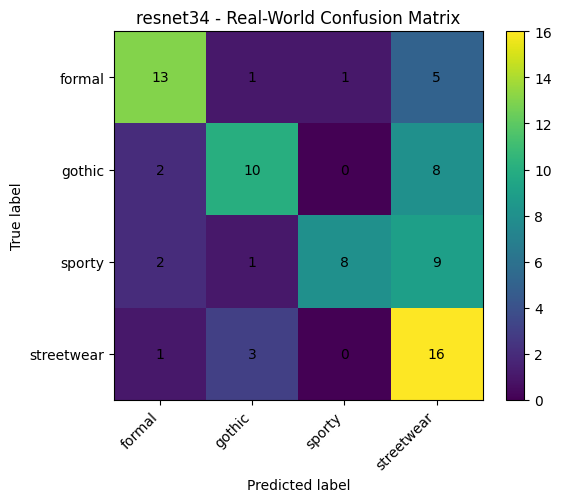

Real-world confusion matrix for: mobilenet_v3_large


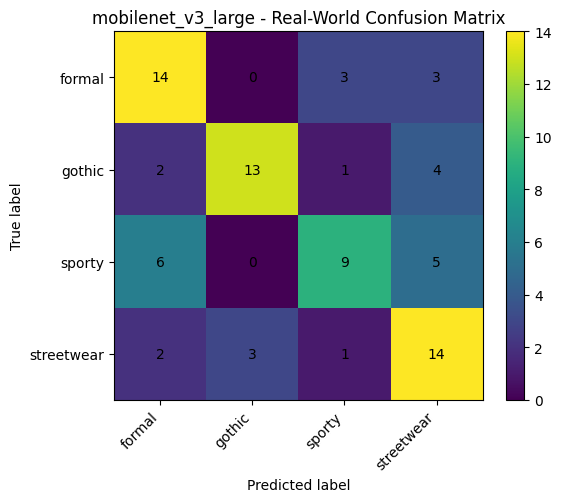

Real-world confusion matrix for: efficientnet_b0


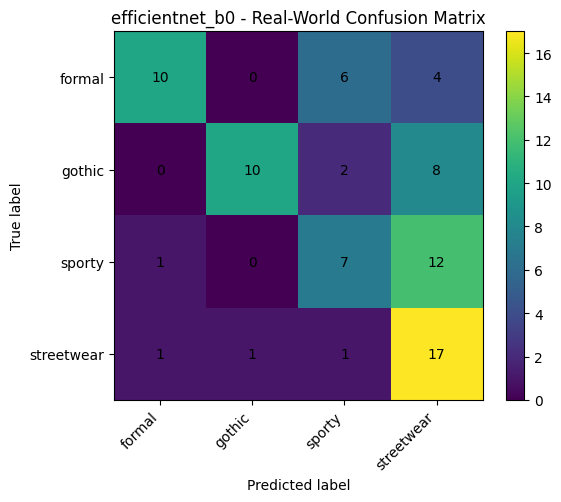

In [40]:
for model_name in model_names:
    print("=" * 80)
    print(f"Real-world confusion matrix for: {model_name}")
    print("=" * 80)

    cm = detailed_evaluations[model_name]["real_world"]["confusion_matrix"]

    save_path = os.path.join(
        results_dir,
        f"{model_name}_real_world_confusion_matrix.png"
    )

    plot_confusion_matrix(
        cm=cm,
        class_names=class_names,
        title=f"{model_name} - Real-World Confusion Matrix",
        save_path=save_path
    )

### 20.1. Save Classification Reports

The classification reports are saved for both the curated test set and the real-world test set.

These reports include precision, recall, and F1-score per class.

In [41]:
for model_name in model_names:
    curated_report = detailed_evaluations[model_name]["curated"]["classification_report_text"]
    real_world_report = detailed_evaluations[model_name]["real_world"]["classification_report_text"]

    with open(os.path.join(results_dir, f"{model_name}_curated_classification_report.txt"), "w") as file:
        file.write(curated_report)

    with open(os.path.join(results_dir, f"{model_name}_real_world_classification_report.txt"), "w") as file:
        file.write(real_world_report)

print("Classification reports saved successfully.")

Classification reports saved successfully.


## 21. Results Interpretation

The architecture comparison showed that the model architecture does affect real-world style classification performance.

The best-performing model on the real-world test set was **MobileNetV3 Large**. It achieved a real-world accuracy of **0.6250** and a real-world macro F1-score of **0.6242**. This was higher than both ResNet34 and EfficientNet-B0.

The current ResNet34 comparison model achieved a real-world accuracy of **0.5875** and a real-world macro F1-score of **0.5898**. This means that MobileNetV3 Large improved real-world accuracy by **0.0375**, or 3.75 percentage points.

EfficientNet-B0 achieved the highest curated test accuracy with **0.8417**, but it performed worst on the real-world test set with **0.5500** accuracy. This is an important result because it confirms an earlier finding from the project: good curated test performance does not automatically mean better real-world generalization.

The result also shows that MobileNetV3 Large is much smaller than ResNet34. MobileNetV3 Large had a model size of approximately **16.25 MB**, while ResNet34 had a model size of approximately **81.34 MB**. This means MobileNetV3 Large was about five times smaller while still achieving better real-world performance.

From a class-level perspective, MobileNetV3 Large also produced the most balanced real-world recall scores:

| Model | Formal recall | Gothic recall | Sporty recall | Streetwear recall |
|---|---:|---:|---:|---:|
| MobileNetV3 Large | 0.70 | 0.65 | 0.45 | 0.70 |
| ResNet34 | 0.65 | 0.50 | 0.40 | 0.80 |
| EfficientNet-B0 | 0.50 | 0.50 | 0.35 | 0.85 |

ResNet34 and EfficientNet-B0 both achieved higher streetwear recall, but they performed worse on other classes, especially sporty and gothic. This suggests that those models may still lean too strongly toward streetwear in uncertain cases.

MobileNetV3 Large did not fully solve the style classification problem, because sporty recall was still weak at **0.45**. However, it provided the best overall balance between real-world accuracy, macro F1-score, class-level performance, and model size.

## 22. Model Selection

Based on the architecture comparison, **MobileNetV3 Large** is selected as the best candidate style model from this experiment.

The reason for selecting MobileNetV3 Large is not only that it achieved the highest real-world accuracy. It also had the best real-world macro F1-score and a much smaller model size compared with ResNet34.

The selected model is:

```text
style_mobilenet_v3_large_architecture_comparison.pth
```

| Reason                         | Explanation                                                                                                |
| ------------------------------ | ---------------------------------------------------------------------------------------------------------- |
| Best real-world accuracy       | MobileNetV3 Large achieved 0.6250 real-world accuracy.                                                     |
| Best real-world macro F1-score | MobileNetV3 Large achieved 0.6242 macro F1-score.                                                          |
| Smaller model size             | MobileNetV3 Large was around 16.25 MB, compared with 81.34 MB for ResNet34.                                |
| Better class balance           | It had better gothic and sporty recall than ResNet34 and EfficientNet-B0.                                  |
| Relevant to teacher feedback   | It directly answers the feedback about testing different architectures such as MobileNet and EfficientNet. |

EfficientNet-B0 is not selected, even though it achieved the highest curated test accuracy. The reason is that it performed worse on real-world images. Since the final application should work with realistic user input images, real-world performance is more important than curated test accuracy.

ResNet34 is also not selected as the best architecture from this comparison. It remains an important baseline, but MobileNetV3 Large performed better while using fewer resources.

Therefore, the next recommendation pipeline experiment should use MobileNetV3 Large as the style classifier and compare its recommendation quality against the current ResNet34-based setup.

## 23. Limitations

This experiment gives useful insight into the effect of model architecture, but it still has some limitations.

First, the comparison only tested three architectures: ResNet34, MobileNetV3 Large, and EfficientNet-B0. These models were selected because they are relevant, feasible, and connected to the teacher feedback. However, this does not mean they are the only possible architectures. Other models such as DenseNet121, ConvNeXt-Tiny, Vision Transformers, or CLIP could still be explored in future work.

Second, the experiment used a frozen feature extractor and trained only the final classification layer. This keeps the comparison controlled and similar to the earlier baseline approach, but it may limit the maximum performance of each model. Some architectures might perform better if part of the model was fine-tuned.

Third, the improved training dataset is intentionally not perfectly balanced. The `style_extra` data adds more examples for formal, sporty, and especially streetwear, but it does not add extra gothic images. This matches the earlier dataset improvement experiment, but it may still influence the model behaviour.

Fourth, the real-world test set contains 80 images. This is useful for checking generalization, but it is still relatively small. A larger real-world test set would make the comparison more reliable.

Finally, this experiment only evaluates style classification. It does not yet test whether the MobileNetV3 Large style model improves the actual recommendation output. That needs to be tested in the next recommendation pipeline experiment.

## 24. Conclusion

This experiment compared ResNet34, MobileNetV3 Large, and EfficientNet-B0 for fashion style classification.

The results showed that MobileNetV3 Large performed best on the real-world test set. It achieved a real-world accuracy of **0.6250** and a real-world macro F1-score of **0.6242**. This was better than ResNet34, which achieved **0.5875** real-world accuracy, and EfficientNet-B0, which achieved **0.5500** real-world accuracy.

EfficientNet-B0 achieved the highest curated test accuracy with **0.8417**, but it did not generalize best to real-world images. This confirms that curated test accuracy alone is not enough to select the best model for this project.

MobileNetV3 Large was also much smaller than ResNet34. It had a model size of approximately **16.25 MB**, compared with approximately **81.34 MB** for ResNet34. This means MobileNetV3 Large gave better real-world performance while using fewer resources.

The main conclusion is that MobileNetV3 Large is the best style model candidate from this architecture comparison. It does not fully solve the style classification problem, especially because sporty recall is still weak, but it provides the best balance between real-world performance, class balance, and model size.

Based on this experiment, MobileNetV3 Large should be tested next inside the full recommendation pipeline.

## 25. Next Step

The next step is to test whether the MobileNetV3 Large style classifier improves the recommendation system.

This should be done by replacing the current ResNet34-based style classifier with the new MobileNetV3 Large style classifier while keeping the rest of the recommendation pipeline the same.

The next experiment should use:

| Component | Selected option |
|---|---|
| Style classifier | MobileNetV3 Large architecture comparison model |
| Type classifier | Existing improved ResNet34 type classifier |
| Recommendation catalogue | Cleaned dataset |
| Recommendation ranking | ResNet34 image embeddings and cosine similarity |
| Evaluation set | Same 32-example recommendation evaluation framework |

The goal of the next experiment should be to answer:

> Does the MobileNetV3 Large style classifier improve recommendation quality compared with the previous ResNet34-based style classifier?

The results should be compared with the current recommendation evaluation scores:

| Criterion | Current score |
|---|---:|
| Structural validity | 1.8750 |
| Style consistency | 1.3125 |
| Visual coherence | 1.3125 |
| Confidence warning usefulness | 1.4688 |
| Overall quality | 1.3125 |

If the MobileNetV3 Large model improves style consistency and overall recommendation quality, then it should replace the current ResNet34 style model in the prototype.

If the recommendation quality does not improve, then the issue is probably not only the architecture. In that case, the next improvement should focus on more balanced boundary-case data, better augmentation, or a different embedding/recommendation method.

## 26. Save Experiment Summary

The final experiment summary is saved as a CSV file.

This summary records the main finding, selected model, and recommended next step.

In [42]:
experiment_summary = {
    "experiment": "style_model_architecture_comparison",
    "models_compared": "ResNet34, MobileNetV3 Large, EfficientNet-B0",
    "selected_model": "MobileNetV3 Large",
    "selected_model_file": "style_mobilenet_v3_large_architecture_comparison.pth",
    "best_real_world_accuracy": 0.6250,
    "best_real_world_macro_f1": 0.6242,
    "main_finding": "MobileNetV3 Large achieved the best real-world style classification performance while being much smaller than ResNet34.",
    "main_limitation": "Sporty recall remains weak and the experiment does not yet test recommendation quality.",
    "next_step": "Test the MobileNetV3 Large style classifier inside the full recommendation pipeline."
}

experiment_summary_df = pd.DataFrame([experiment_summary])

experiment_summary_df.to_csv(
    os.path.join(results_dir, "architecture_comparison_experiment_summary.csv"),
    index=False
)

experiment_summary_df

,experiment,models_compared,selected_model,selected_model_file,best_real_world_accuracy,best_real_world_macro_f1,main_finding,main_limitation,next_step
0,style_model_architecture_comparison,"ResNet34, MobileNetV3 Large, EfficientNet-B0",MobileNetV3 Large,style_mobilenet_v3_large_architecture_comparis...,0.625,0.6242,MobileNetV3 Large achieved the best real-world...,Sporty recall remains weak and the experiment ...,Test the MobileNetV3 Large style classifier in...
